<a href="https://colab.research.google.com/github/Fentahun60/Fentahun/blob/main/NMR_trial_%3D_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [54]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Statistical model
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

# Machine learning preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Time series validation
from sklearn.model_selection import TimeSeriesSplit

In [55]:
import pandas as pd
import requests
import io
import re

drive_url = 'https://drive.google.com/file/d/1rsJt4QXWlwA1WU8Z3k31sWKNGUHx0lDA/view?usp=sharing'

df = pd.DataFrame() # Initialize df as an empty DataFrame

try:
    file_id_match = re.search(r'/d/([a-zA-Z0-9_-]+)', drive_url)
    if file_id_match:
        file_id = file_id_match.group(1)
        download_url = f'https://drive.google.com/uc?export=download&id={file_id}'

        response = requests.get(download_url)
        response.raise_for_status()

        df = pd.read_csv(io.StringIO(response.text))
        print("DataFrame loaded successfully from Google Drive.")
    else:
        print("Could not extract file ID from the provided URL.")
except requests.exceptions.RequestException as e:
    print(f"Error fetching data from Google Drive: {e}")
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")


DataFrame loaded successfully from Google Drive.


In [56]:
df = df.sort_values("Year")

df.head()

,Year,NNM,LOWER_BOUND,UPPER_BOUND
0,1977-06,66.39,57.20,76.29
1,1978-06,66.55,58.02,75.99
2,1979-06,66.76,58.77,75.80
3,1980-06,66.91,59.29,75.64
4,1981-06,66.86,59.39,75.09


In [57]:
df['Year'] = pd.to_datetime(df['Year'], format='%Y-%m').dt.year

df.head()

,Year,NNM,LOWER_BOUND,UPPER_BOUND
0,1977,66.39,57.20,76.29
1,1978,66.55,58.02,75.99
2,1979,66.76,58.77,75.80
3,1980,66.91,59.29,75.64
4,1981,66.86,59.39,75.09


In [58]:
df.isnull().sum()

,0
Year,0
NNM,0
LOWER_BOUND,0
UPPER_BOUND,0


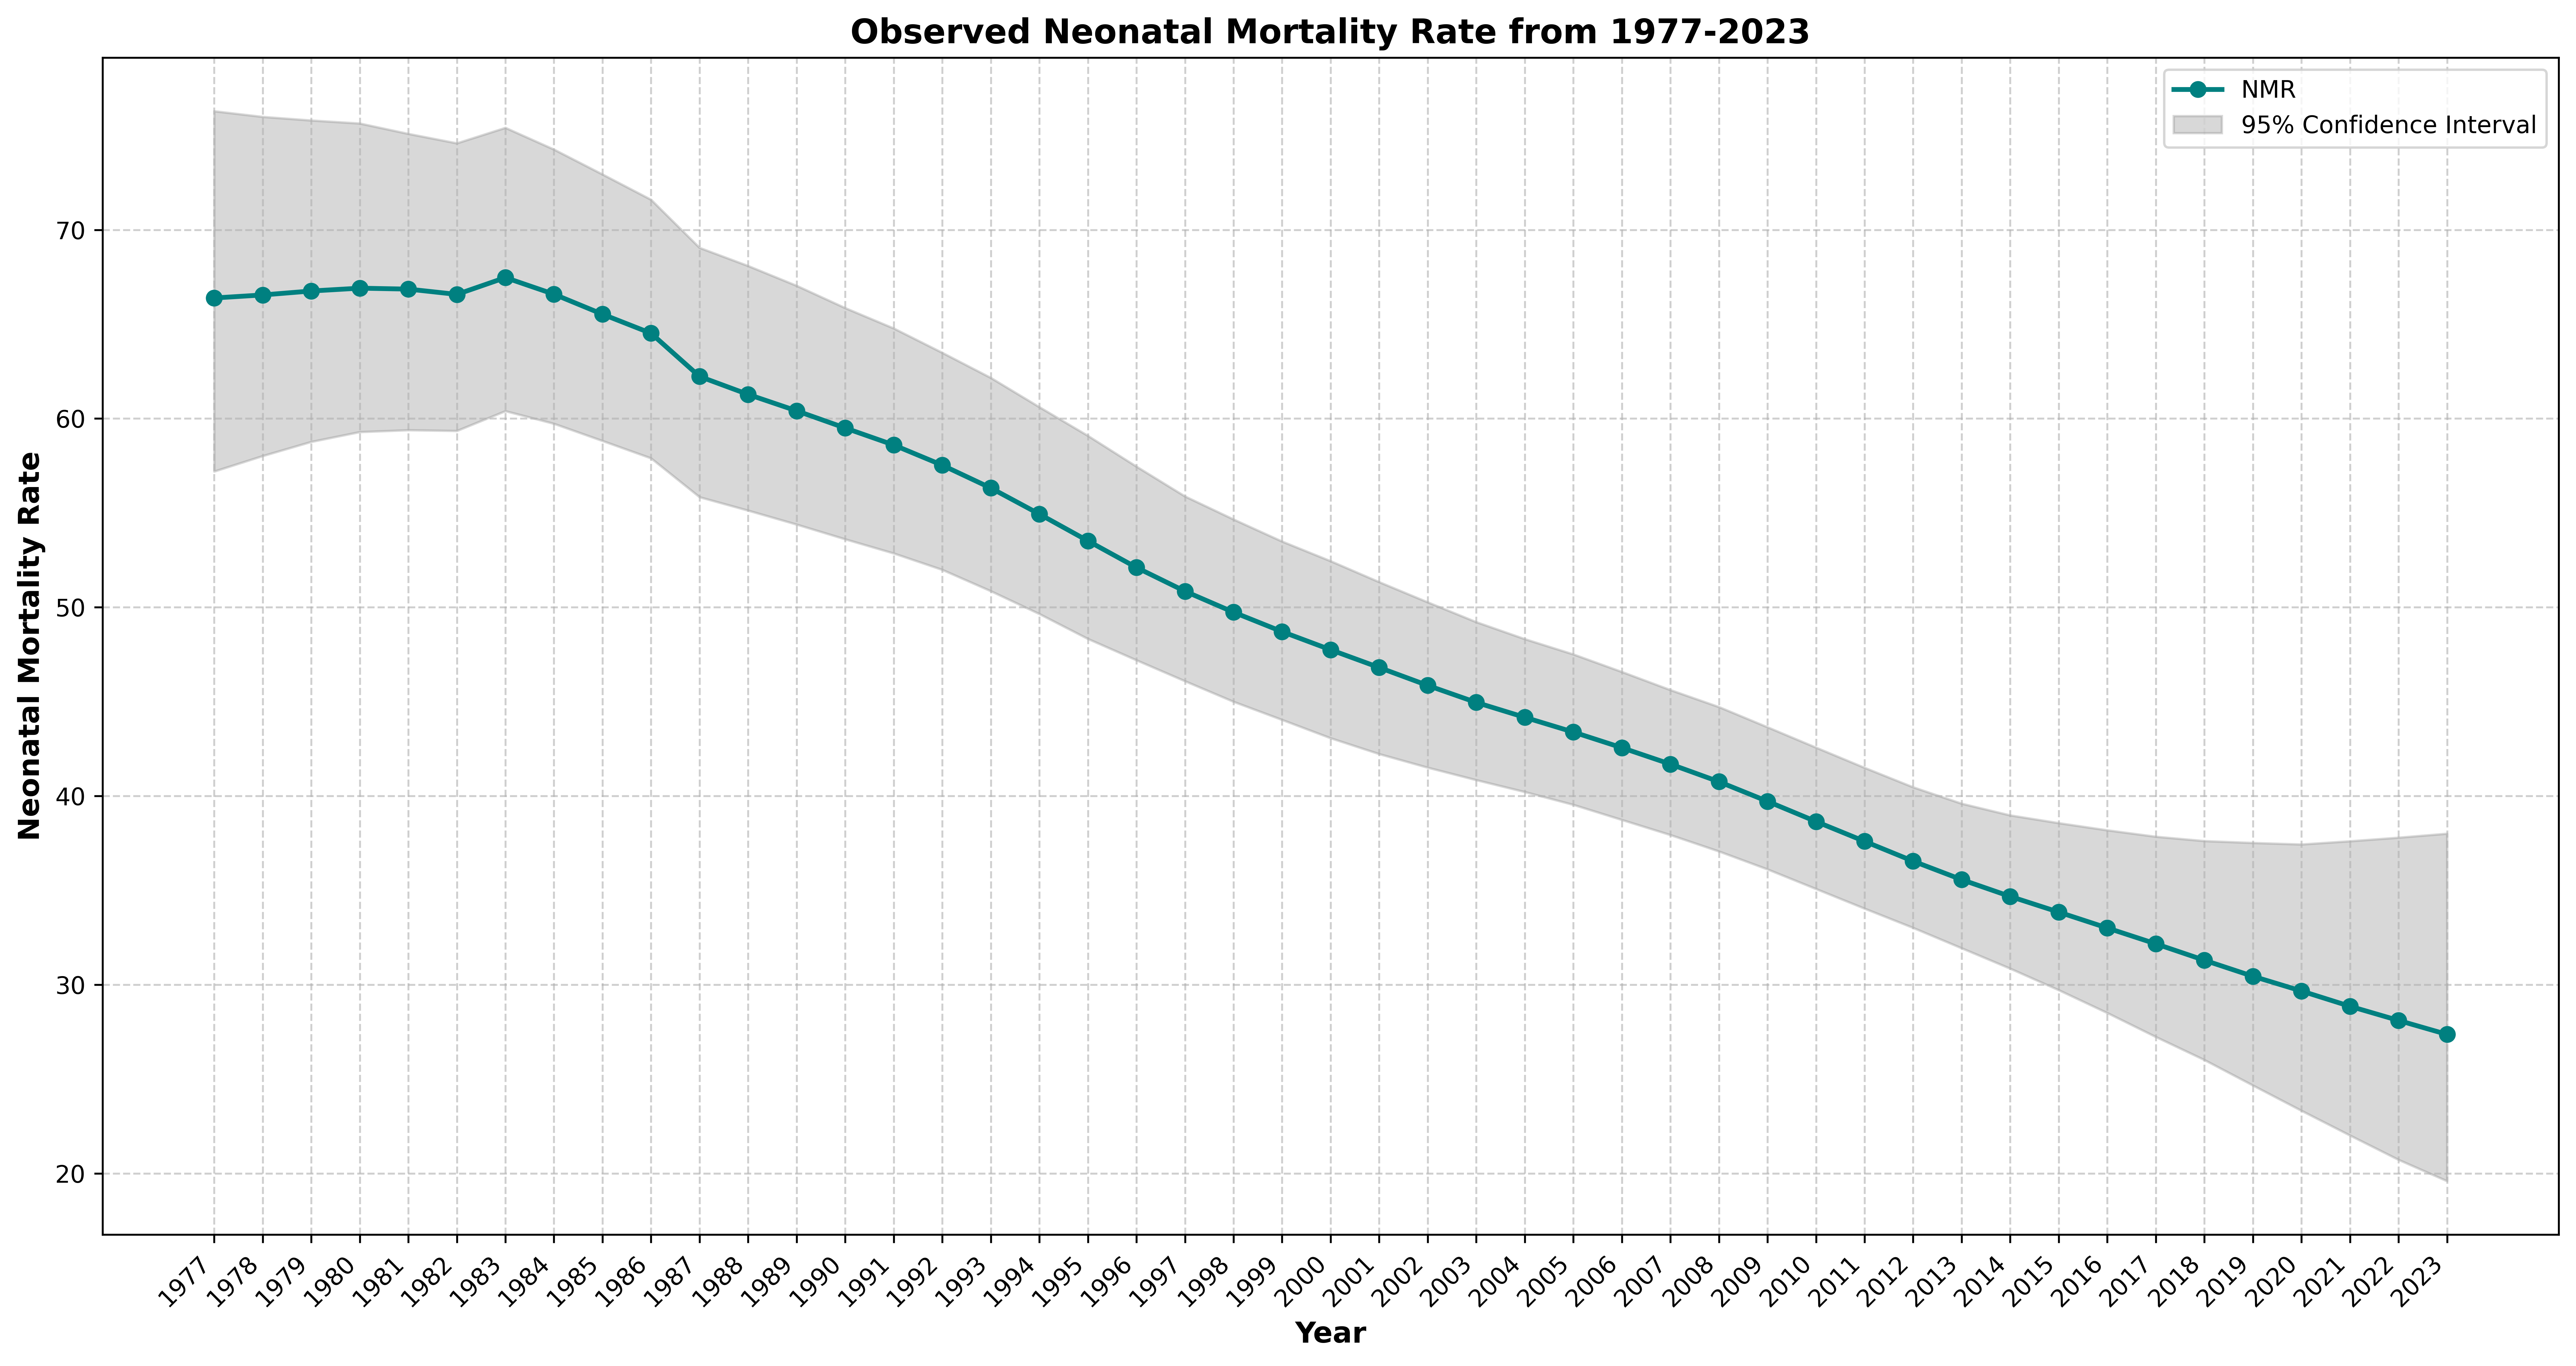

In [59]:
plt.figure(figsize=(15, 8), dpi=600)

plt.plot(df['Year'], df['NNM'], marker='o', linestyle='-', color='teal', linewidth=2, label='NMR')

# Include lower and upper bound
plt.fill_between(df['Year'], df['LOWER_BOUND'], df['UPPER_BOUND'], color='gray', alpha=0.3, label='95% Confidence Interval')

plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Neonatal Mortality Rate", fontsize=12, fontweight='bold')

plt.title("Observed Neonatal Mortality Rate from 1977-2023", fontsize=14, fontweight='bold')

# Display all years on the x-axis and rotate for readability
plt.xticks(df['Year'], rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.savefig('observed_timeseries.png', dpi=600)
plt.show()

In [60]:
train_size=int(len(df)*0.8)

train=df.iloc[:train_size]

test=df.iloc[train_size:]

print(train.shape)
print(test.shape)

(37, 4)
(10, 4)


In [61]:
result=adfuller(train['NNM'])

print("ADF statistic:",result[0])
print("p-value:",result[1])

ADF statistic: -2.023511076423584
p-value: 0.2763603959980818


In [62]:
# First-order differencing
train_diff = train['NNM'].diff().dropna()

# ADF test again
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(train_diff)

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF statistic: -4.502300528502333
p-value: 0.00019476630948323052


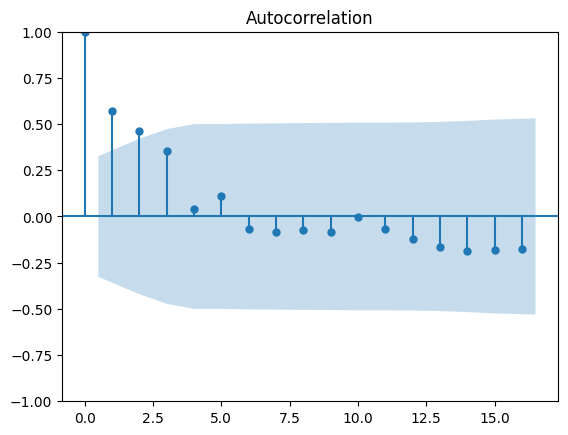

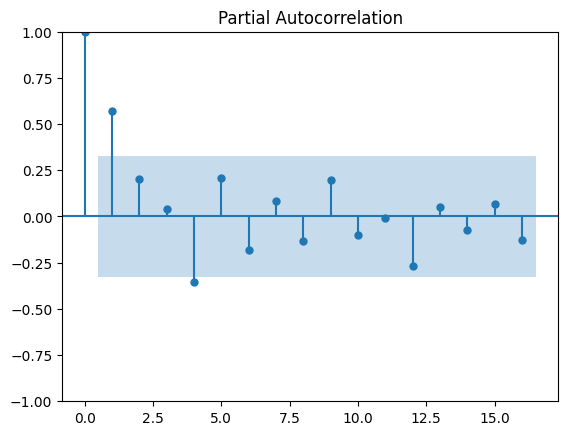

In [63]:
plot_acf(train_diff)

plt.show()
plot_pacf(train_diff)

plt.show()

In [64]:
model_arima=ARIMA(
    train['NNM'],
    order=(1,1,1)
)

arima_fit=model_arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                    NNM   No. Observations:                   37
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -21.532
Date:                Sat, 18 Jul 2026   AIC                             49.065
Time:                        13:50:24   BIC                             53.815
Sample:                             0   HQIC                            50.723
                                 - 37                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9618      0.082     11.688      0.000       0.801       1.123
ma.L1         -0.4361      0.147     -2.965      0.003      -0.724      -0.148
sigma2         0.1847      0.026      7.176      0.0

In [65]:
print("AIC:",arima_fit.aic)

print("BIC:",arima_fit.bic)

AIC: 49.06484872042939
BIC: 53.81540553579772


In [66]:
acorr_ljungbox(
    arima_fit.resid,
    lags=[10],
    return_df=True
)

,lb_stat,lb_pvalue
10,0.098724,1.0


In [67]:
orders = [(1,1,0), (0,1,1), (2,1,1), (1,1,1)]
results_list = []

for order in orders:
    model = ARIMA(train['NNM'], order=order)
    results = model.fit()
    results_list.append({
        'Model': f'ARIMA{order}',
        'AIC': round(results.aic, 3),
        'BIC': round(results.bic, 3)
    })

# Create a DataFrame to display results in table form
comparison_table = pd.DataFrame(results_list)
comparison_table

,Model,AIC,BIC
0,"ARIMA(1, 1, 0)",53.073,56.240
1,"ARIMA(0, 1, 1)",76.885,80.052
2,"ARIMA(2, 1, 1)",50.743,57.077
3,"ARIMA(1, 1, 1)",49.065,53.815


In [68]:
arima_prediction=arima_fit.forecast(
    steps=len(test)
)

In [69]:
actual = test['NNM']
predicted = arima_prediction

# 1. MAE
mae = mean_absolute_error(actual, predicted)

# 2. RMSE
rmse = np.sqrt(mean_squared_error(actual, predicted))

# 3. MAPE
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

# 4. sMAPE
smape = 100/len(actual) * np.sum(2 * np.abs(predicted - actual) / (np.abs(actual) + np.abs(predicted)))

# 5. MASE
# MASE requires the mean absolute error of the naive forecast from the training set
naive_mae = np.mean(np.abs(np.diff(train['NNM'])))
mase = mae / naive_mae

metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae, rmse, mape, smape, mase]
})

display(metrics_df)

,Metric,Value
0,MAE,0.116037
1,RMSE,0.136442
2,MAPE (%),0.384322
3,sMAPE (%),0.383931
4,MASE,0.124177


In [87]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract residuals from the fitted ARIMA model
arima_residuals = arima_fit.resid

# 2. Residual Diagnostic Plots (High Quality 600 DPI)
fig, axes = plt.subplots(1, 3, figsize=(22, 7), dpi=600)

# Plot 1: Standardized Residuals over time
axes[0].plot(arima_residuals, color='#008080', linewidth=1.5)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.6)
axes[0].set_title('Standardized Residuals', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Residual')
axes[0].grid(True, linestyle=':', alpha=0.5)

# Plot 2: Histogram and KDE (Normality check)
sns.histplot(arima_residuals, kde=True, ax=axes[1], color='#008080', stat="density")
axes[1].set_title('Residual Distribution (Normality)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Residual Value')

# Plot 3: ACF of Residuals (Autocorrelation check)
sm.graphics.tsa.plot_acf(arima_residuals, lags=20, ax=axes[2], color='#008080')
axes[2].set_title('Residual ACF (Independence)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('arima_diagnostics_600dpi.png', dpi=600, bbox_inches='tight')
plt.show()

# 3. Formal Statistical Tests with Detailed Interpretation
print("="*50)
print("       ARIMA RESIDUAL DIAGNOSTIC RESULTS")
print("="*50)

# Ljung-Box Test for Autocorrelation
lb_test = acorr_ljungbox(arima_residuals, lags=[10], return_df=True)
p_val_lb = lb_test['lb_pvalue'].iloc[0]
print(f"\n1. Ljung-Box Test (Independence):")
print(f"   - Stat: {lb_test['lb_stat'].iloc[0]:.4f}, p-value: {p_val_lb:.4f}")
if p_val_lb > 0.05:
    print("   - INTERPRETATION: Pass. p > 0.05, so we fail to reject the null hypothesis.")
    print("     The residuals are independent (white noise), meaning the model captured the trend.")
else:
    print("   - INTERPRETATION: Fail. p < 0.05 suggests significant autocorrelation remains.")

# Shapiro-Wilk Test for Normality
shapiro_stat, shapiro_p = shapiro(arima_residuals)
print(f"\n2. Shapiro-Wilk Test (Normality):")
print(f"   - Statistic: {shapiro_stat:.4f}, p-value: {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("   - INTERPRETATION: Pass. p > 0.05 suggests residuals are normally distributed.")
else:
    print("   - INTERPRETATION: Fail. p < 0.05 indicates residuals are not normally distributed.")
    print("     This is common in mortality data due to extreme values or structural skew.")
print("="*50)

       ARIMA RESIDUAL DIAGNOSTIC RESULTS

1. Ljung-Box Test (Independence):
   - Stat: 0.0987, p-value: 1.0000
   - INTERPRETATION: Pass. p > 0.05, so we fail to reject the null hypothesis.
     The residuals are independent (white noise), meaning the model captured the trend.

2. Shapiro-Wilk Test (Normality):
   - Statistic: 0.1809, p-value: 0.0000
   - INTERPRETATION: Fail. p < 0.05 indicates residuals are not normally distributed.
     This is common in mortality data due to extreme values or structural skew.


In [70]:
scaler=MinMaxScaler()

train_scaled=scaler.fit_transform(
train[['NNM']]
)

test_scaled=scaler.transform(
test[['NNM']]
)

In [71]:
def create_dataset(data,window=5):

    X=[]
    y=[]

    for i in range(len(data)-window):

        X.append(data[i:i+window])

        y.append(data[i+window])

    return np.array(X),np.array(y)



X_train,y_train=create_dataset(
train_scaled,
5
)


X_test,y_test=create_dataset(
test_scaled,
5
)

In [72]:
model=Sequential()

model.add(
LSTM(
50,
activation='relu',
input_shape=(5,1)
)
)

model.add(Dense(1))


model.compile(
optimizer=Adam(learning_rate=0.001),
loss='mse'
)


model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
early_stop=EarlyStopping(
monitor='val_loss',
patience=20,
restore_best_weights=True
)


history=model.fit(
X_train,
y_train,
epochs=200,
batch_size=32,
validation_split=0.2,
callbacks=[early_stop]
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.5107 - val_loss: 0.0159
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.4978 - val_loss: 0.0148
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.4850 - val_loss: 0.0138
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.4725 - val_loss: 0.0128
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.4602 - val_loss: 0.0119
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 0.4481 - val_loss: 0.0111
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 0.4363 - val_loss: 0.0103
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - loss: 0.4247 - val_loss: 0.0095
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.4133 - val_loss: 0.0088
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - loss: 0.4022 - val_loss: 0.0082
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - loss: 0.3913 - val_loss: 0.0076
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 0.3805 - val_l

In [74]:
lstm_pred=model.predict(X_test)

lstm_pred=scaler.inverse_transform(
lstm_pred
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step


In [75]:
y_test_original=scaler.inverse_transform(
y_test
)

In [76]:
actual_lstm = y_test_original.flatten()
predicted_lstm = lstm_pred.flatten()

# 1. MAE
mae_lstm = mean_absolute_error(actual_lstm, predicted_lstm)

# 2. RMSE
rmse_lstm = np.sqrt(mean_squared_error(actual_lstm, predicted_lstm))

# 3. MAPE
mape_lstm = np.mean(np.abs((actual_lstm - predicted_lstm) / actual_lstm)) * 100

# 4. sMAPE
smape_lstm = 100/len(actual_lstm) * np.sum(2 * np.abs(predicted_lstm - actual_lstm) / (np.abs(actual_lstm) + np.abs(predicted_lstm)))

# 5. MASE
# Using the same naive MAE from the training set calculated previously
naive_mae = np.mean(np.abs(np.diff(train['NNM'])))
mase_lstm = mae_lstm / naive_mae

lstm_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae_lstm, rmse_lstm, mape_lstm, smape_lstm, mase_lstm]
})

print("LSTM Model Evaluation Metrics:")
display(lstm_metrics_df)

LSTM Model Evaluation Metrics:


,Metric,Value
0,MAE,7.738804
1,RMSE,7.779566
2,MAPE (%),26.927739
3,sMAPE (%),23.683760
4,MASE,8.281717


In [77]:
residuals=train['NNM']-arima_fit.fittedvalues

In [78]:
# 1. Scale the residuals
res_scaler = MinMaxScaler(feature_range=(-1, 1))
res_values = residuals.values.reshape(-1, 1)
scaled_residuals = res_scaler.fit_transform(res_values)

# 2. Create the dataset for LSTM (using window size 5)
def create_residual_dataset(data, window=5):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i + window])
        y.append(data[i + window])
    return np.array(X), np.array(y)

window_size = 5
X_res, y_res = create_residual_dataset(scaled_residuals, window_size)

# 3. Build the LSTM model for residuals
res_model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1), return_sequences=False),
    Dense(1)
])

res_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 4. Train the model
early_stop_res = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

print("Training LSTM on ARIMA residuals...")
res_history = res_model.fit(
    X_res, y_res,
    epochs=100,
    batch_size=8,
    verbose=1,
    callbacks=[early_stop_res]
)

print("\nResidual LSTM training complete.")

Training LSTM on ARIMA residuals...
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8202  
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.7488
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6843 
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6253 
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5708 
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5181 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.4667 
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4149 
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3617 
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3072 
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2516 
Epoch 12/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1963 
Epoch 13/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1432 
Epoch 14/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0938 
Epoch 15/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0523 
Epoch 16/100
4/4 ━━━━━━━━━━━━━

In [79]:
# 1. Prepare input for LSTM residual forecast
# We use the last 'window_size' residuals from the training set to start predicting
last_resid_window = scaled_residuals[-window_size:].reshape(1, window_size, 1)

# 2. Forecast residuals for the test period
lstm_resid_forecast = []
current_window = last_resid_window

for _ in range(len(test)):
    pred = res_model.predict(current_window, verbose=0)
    lstm_resid_forecast.append(pred[0, 0])
    # Update window: remove first, append predicted
    current_window = np.append(current_window[:, 1:, :], pred.reshape(1, 1, 1), axis=1)

# 3. Inverse transform the residual forecast
lstm_resid_forecast_rescaled = res_scaler.inverse_transform(np.array(lstm_resid_forecast).reshape(-1, 1)).flatten()

# 4. Hybrid Prediction = ARIMA forecast + LSTM residual forecast
hybrid_prediction = arima_prediction.values + lstm_resid_forecast_rescaled

# Display Results
hybrid_results = pd.DataFrame({
    'Year': test['Year'],
    'Actual': test['NNM'],
    'ARIMA': arima_prediction.values,
    'Hybrid': hybrid_prediction
})

print("Hybrid Model Prediction Results:")
display(hybrid_results.head())

# 5. Comprehensive Evaluation of Hybrid Model
actual_vals = test['NNM'].values

# MAE
mae_hybrid = mean_absolute_error(actual_vals, hybrid_prediction)
# RMSE
rmse_hybrid = np.sqrt(mean_squared_error(actual_vals, hybrid_prediction))
# MAPE
mape_hybrid = np.mean(np.abs((actual_vals - hybrid_prediction) / actual_vals)) * 100
# sMAPE
smape_hybrid = 100/len(actual_vals) * np.sum(2 * np.abs(hybrid_prediction - actual_vals) / (np.abs(actual_vals) + np.abs(hybrid_prediction)))
# MASE
# Re-using the naive_mae from training data calculated earlier
naive_mae = np.mean(np.abs(np.diff(train['NNM'])))
mase_hybrid = mae_hybrid / naive_mae

hybrid_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae_hybrid, rmse_hybrid, mape_hybrid, smape_hybrid, mase_hybrid]
})

print("\nHybrid Model Evaluation Metrics:")
display(hybrid_metrics_df)

Hybrid Model Prediction Results:


,Year,Actual,ARIMA,Hybrid
37,2014,34.68,34.629518,34.535686
38,2015,33.85,33.724953,33.655731
39,2016,33.01,32.854934,32.805681
40,2017,32.17,32.018141,31.977446
41,2018,31.30,31.213306,31.179862



Hybrid Model Evaluation Metrics:


,Metric,Value
0,MAE,0.142348
1,RMSE,0.159260
2,MAPE (%),0.461190
3,sMAPE (%),0.461258
4,MASE,0.152335


In [80]:
# 1. Prepare multi-step dataset (Window=5, Steps=7)
def create_multistep_dataset(data, window=5, steps=7):
    X, y = [], []
    for i in range(len(data) - window - steps + 1):
        X.append(data[i:i + window])
        y.append(data[i + window:i + window + steps])
    return np.array(X), np.array(y).reshape(-1, steps)

window_size = 5
forecast_steps = 7

X_multi, y_multi = create_multistep_dataset(train_scaled, window_size, forecast_steps)

# 2. Build Multi-step LSTM Model
multi_step_model = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, 1), return_sequences=False),
    Dense(32, activation='relu'),
    Dense(forecast_steps)
])

multi_step_model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# 3. Train the model
early_stop_multi = EarlyStopping(monitor='loss', patience=15, restore_best_weights=True)

print(f"Training Multi-step LSTM to predict next {forecast_steps} steps...")
multi_history = multi_step_model.fit(
    X_multi, y_multi,
    epochs=200,
    batch_size=16,
    verbose=0,
    callbacks=[early_stop_multi]
)

# 4. Generate multi-step forecast
last_train_window = train_scaled[-window_size:].reshape(1, window_size, 1)
multi_step_pred_scaled = multi_step_model.predict(last_train_window, verbose=0)
multi_step_pred = scaler.inverse_transform(multi_step_pred_scaled).flatten()

# 5. Evaluation against the test set (first 7 steps)
actual_multi = test['NNM'].values[:forecast_steps]

mae_ms = mean_absolute_error(actual_multi, multi_step_pred)
rmse_ms = np.sqrt(mean_squared_error(actual_multi, multi_step_pred))
mape_ms = np.mean(np.abs((actual_multi - multi_step_pred) / actual_multi)) * 100
smape_ms = 100/len(actual_multi) * np.sum(2 * np.abs(multi_step_pred - actual_multi) / (np.abs(actual_multi) + np.abs(multi_step_pred)))
# Re-using naive_mae from training data
naive_mae = np.mean(np.abs(np.diff(train['NNM'])))
mase_ms = mae_ms / naive_mae

multi_metrics_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'sMAPE (%)', 'MASE'],
    'Value': [mae_ms, rmse_ms, mape_ms, smape_ms, mase_ms]
})

print("Multi-step LSTM Forecast for the next 7 years:")
for i, val in enumerate(multi_step_pred):
    print(f"Year {i+1}: {val:.2f}")

print("\nMulti-step Evaluation Metrics:")
display(multi_metrics_df)

Training Multi-step LSTM to predict next 7 steps...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Multi-step LSTM Forecast for the next 7 years:
Year 1: 38.56
Year 2: 37.81
Year 3: 36.81
Year 4: 36.15
Year 5: 35.73
Year 6: 34.78
Year 7: 33.75

Multi-step Evaluation Metrics:


,Metric,Value
0,MAE,4.066037
1,RMSE,4.071828
2,MAPE (%),12.700301
3,sMAPE (%),11.935811
4,MASE,4.351288


In [81]:
results = pd.DataFrame({
    "Model": [
        "ARIMA",
        "LSTM",
        "Multistep LSTM",
        "Hybrid"
    ],
    "MAE": [
        mae,
        mae_lstm,
        mae_ms,
        mae_hybrid
    ],
    "RMSE": [
        rmse,
        rmse_lstm,
        rmse_ms,
        rmse_hybrid
    ],
    "MAPE (%)": [
        mape,
        mape_lstm,
        mape_ms,
        mape_hybrid
    ],
    "sMAPE (%)": [
        smape,
        smape_lstm,
        smape_ms,
        smape_hybrid
    ],
    "MASE": [
        mase,
        mase_lstm,
        mase_ms,
        mase_hybrid
    ]
})

print("Final Model Comparison Table (ARIMA values from Cell 33):")
display(results)

Final Model Comparison Table (ARIMA values from Cell 33):


,Model,MAE,RMSE,MAPE (%),sMAPE (%),MASE
0,ARIMA,0.116037,0.136442,0.384322,0.383931,0.124177
1,LSTM,7.738804,7.779566,26.927739,23.683760,8.281717
2,Multistep LSTM,4.066037,4.071828,12.700301,11.935811,4.351288
3,Hybrid,0.142348,0.159260,0.461190,0.461258,0.152335


In [83]:
# 1. Prepare Full Data and Scaler
full_data = df[['NNM']].values
full_scaled = scaler.fit_transform(full_data)

# 2. Refit ARIMA on full data and forecast
model_arima_full = ARIMA(df['NNM'], order=(1,1,1))
arima_fit_full = model_arima_full.fit()
arima_forecast_res = arima_fit_full.get_forecast(steps=7)
arima_forecast_vals = arima_forecast_res.predicted_mean
conf_int_arima = arima_forecast_res.conf_int(alpha=0.05)

# 3. Forecast using LSTM (Recursive)
last_window = full_scaled[-5:].reshape(1, 5, 1)
lstm_forecast_scaled = []
curr_window = last_window.copy()
for _ in range(7):
    p = model.predict(curr_window, verbose=0)
    lstm_forecast_scaled.append(p[0,0])
    curr_window = np.append(curr_window[:, 1:, :], p.reshape(1,1,1), axis=1)
lstm_forecast = scaler.inverse_transform(np.array(lstm_forecast_scaled).reshape(-1,1)).flatten()

# 4. Forecast using Hybrid (ARIMA + Residual LSTM)
res_full = df['NNM'] - arima_fit_full.fittedvalues
res_scaled_full = res_scaler.fit_transform(res_full.values.reshape(-1,1))
last_res_window = res_scaled_full[-5:].reshape(1, 5, 1)
res_forecast_scaled = []
curr_res_window = last_res_window.copy()
for _ in range(7):
    p = res_model.predict(curr_res_window, verbose=0)
    res_forecast_scaled.append(p[0,0])
    curr_res_window = np.append(curr_res_window[:, 1:, :], p.reshape(1,1,1), axis=1)
res_forecast = res_scaler.inverse_transform(np.array(res_forecast_scaled).reshape(-1,1)).flatten()
hybrid_forecast = arima_forecast_vals.values + res_forecast

# 5. Forecast using Multistep LSTM
multi_forecast_scaled = multi_step_model.predict(last_window, verbose=0)
multi_forecast = scaler.inverse_transform(multi_forecast_scaled).flatten()

# 6. Estimate 95% CI for Neural Models (using residual std dev as proxy)
lstm_std = np.std(actual_lstm - predicted_lstm)
hybrid_std = np.std(actual_vals - hybrid_prediction)
multi_std = np.std(actual_multi - multi_step_pred)

z_score = 1.96

def fmt_ci(val, std):
    return f"{val:.2f} ({val - z_score*std:.2f}-{val + z_score*std:.2f})"

forecast_years = np.arange(2024, 2031)
forecast_df = pd.DataFrame({
    'Year': forecast_years,
    'ARIMA': [f"{v:.2f} ({l:.2f}-{u:.2f})" for v, l, u in zip(arima_forecast_vals, conf_int_arima.iloc[:, 0], conf_int_arima.iloc[:, 1])],
    'LSTM': [fmt_ci(v, lstm_std) for v in lstm_forecast],
    'Multistep LSTM': [fmt_ci(v, multi_std) for v in multi_forecast],
    'Hybrid': [fmt_ci(v, hybrid_std) for v in hybrid_forecast]
})

print("Forecast Results (2024-2030) with 95% Confidence Intervals:")
display(forecast_df)

Forecast Results (2024-2030) with 95% Confidence Intervals:


,Year,ARIMA,LSTM,Multistep LSTM,Hybrid
0,2024,26.66 (25.91-27.41),30.45 (28.89-32.01),30.69 (30.27-31.12),26.67 (26.36-26.97)
1,2025,25.97 (24.61-27.33),30.52 (28.97-32.08),29.76 (29.33-30.19),25.99 (25.69-26.29)
2,2026,25.31 (23.27-27.35),30.60 (29.04-32.15),28.48 (28.05-28.90),25.33 (25.02-25.63)
3,2027,24.67 (21.90-27.45),30.66 (29.11-32.22),27.69 (27.26-28.11),24.70 (24.40-25.00)
4,2028,24.05 (20.49-27.62),30.74 (29.18-32.30),27.10 (26.67-27.52),24.08 (23.78-24.39)
5,2029,23.46 (19.06-27.85),30.81 (29.25-32.37),26.01 (25.58-26.43),23.50 (23.19-23.80)
6,2030,22.88 (17.61-28.15),30.83 (29.27-32.38),24.73 (24.31-25.16),22.93 (22.62-23.23)


In [85]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
hist_years = df['Year']
hist_values = df['NNM']
forecast_years = np.arange(2024, 2031)

# Create a 2x2 grid with high DPI for publication quality
fig, axes = plt.subplots(2, 2, figsize=(20, 14), dpi=600)
axes = axes.flatten()

models = ['ARIMA', 'LSTM', 'Multistep LSTM', 'Hybrid']
forecast_data = [arima_forecast_vals, lstm_forecast, multi_forecast, hybrid_forecast]
stds = [None, lstm_std, multi_std, hybrid_std]

for i, (name, forecast, std) in enumerate(zip(models, forecast_data, stds)):
    ax = axes[i]

    # Plot Historical Data
    ax.plot(hist_years, hist_values, label='Historical Observed', color='#2c3e50', alpha=0.7, linewidth=2)

    # Plot Forecasted Data
    ax.plot(forecast_years, forecast, label=f'{name} Forecast', color='#d35400', marker='o', markersize=6, linewidth=2.5)

    # Calculate and Plot 95% Confidence Intervals
    if name == 'ARIMA':
        lower = conf_int_arima.iloc[:, 0]
        upper = conf_int_arima.iloc[:, 1]
    else:
        # Using 1.96 standard deviations for 95% CI
        lower = forecast - (1.96 * std)
        upper = forecast + (1.96 * std)

    ax.fill_between(forecast_years, lower, upper, color='#e67e22', alpha=0.25, label='95% Confidence Interval')

    # Formatting
    ax.set_title(f'{name} Model: History & 7-Year Forecast', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Neonatal Mortality Rate', fontsize=12)
    ax.legend(loc='upper right', frameon=True, shadow=True)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_facecolor('#fdfefe')

plt.tight_layout(pad=4.0)
plt.savefig('final_model_forecasts_600dpi.png', dpi=600, bbox_inches='tight')
plt.show()